In [11]:
#import a .csv file and print its top 10 lines
import pandas as pd

imported_data=pd.read_csv('final_project_data.csv')
#print its top 10 lines
print(imported_data.head(10))


          Date   Site_ID Site_type  StartTime  TimeSeg BirdMamm  \
0  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
1  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
2  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
3  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
4  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
5  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
6  2019-Nov-05  VAR2_10R  Restored       6.46        1   MAMMAL   
7  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
8  2019-Nov-05  VAR2_10R  Restored       6.46        2     Bird   
9  2019-Nov-05  VAR2_10R  Restored       6.46        2     Bird   

                                   Species  Number  Distance HSF Remarks  
0                         Greenish Warbler       1         5   H     NaN  
1                Large-billed Leaf Warbler       1        30   H     NaN  
2                     Yellow-browed B

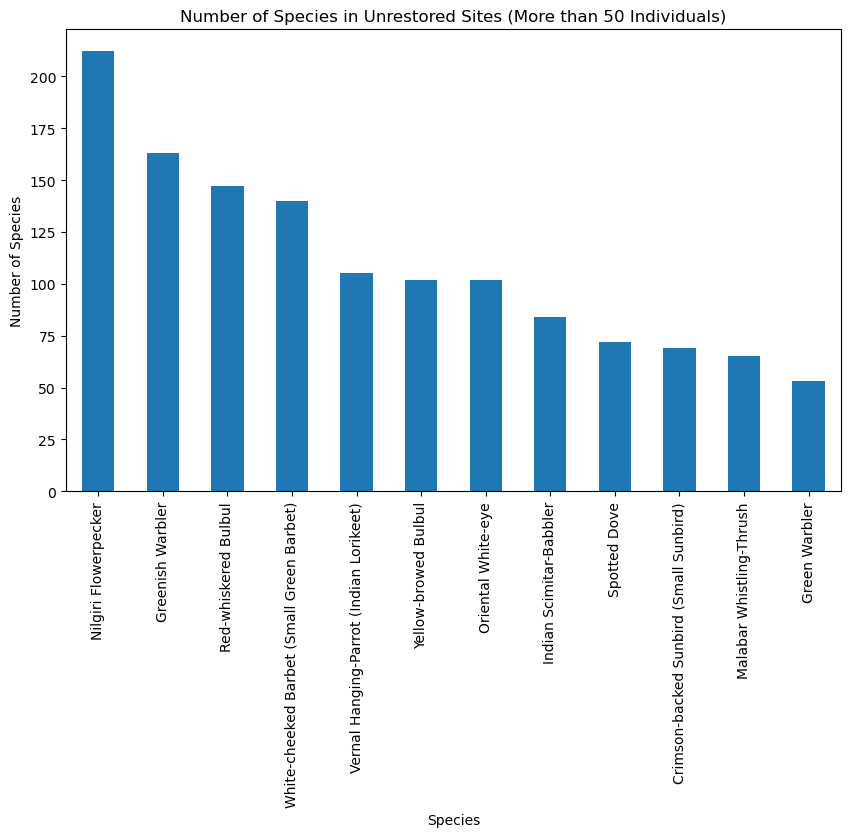

In [12]:
#plot graph of unrestored Site_type Species and Species number only if there are more than 50 individuals 

#on the x-axis plot the Species, on the y-axis plot the number of Species 
import matplotlib.pyplot as plt
unrestored_data=imported_data[imported_data['Site_type']=='Unrestored']
species_counts=unrestored_data['Species'].value_counts()
filtered_species_counts=species_counts[species_counts>50]
plt.figure(figsize=(10,6))
filtered_species_counts.plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Number of Species')
plt.title('Number of Species in Unrestored Sites (More than 50 Individuals)')
plt.show()

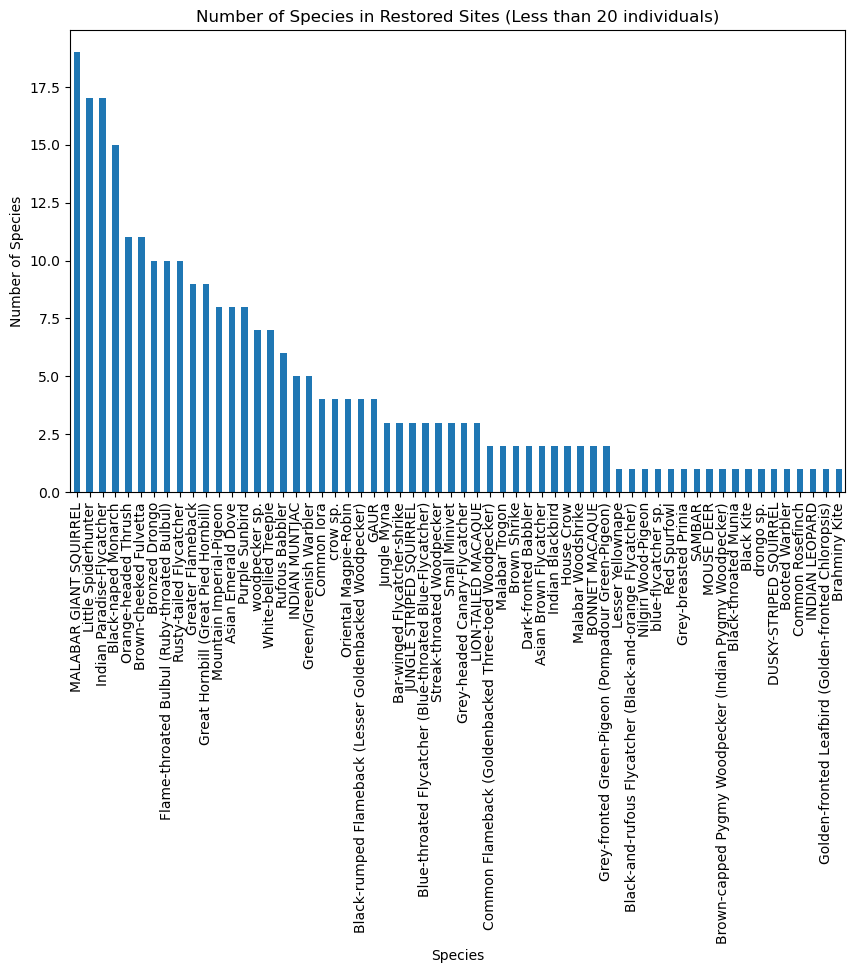

In [13]:
#plot graph of restored Site_type Species and Species number only if there are less than 20 individuals 

#on the x-axis plot the Species, on the y-axis plot the number of Species 
import matplotlib.pyplot as plt
restored_data=imported_data[imported_data['Site_type']=='Restored'] 
species_counts=restored_data['Species'].value_counts()
filtered_species_counts=species_counts[species_counts<20]
plt.figure(figsize=(10,6))
filtered_species_counts.plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Number of Species')
plt.title('Number of Species in Restored Sites (Less than 20 individuals)')
plt.show()

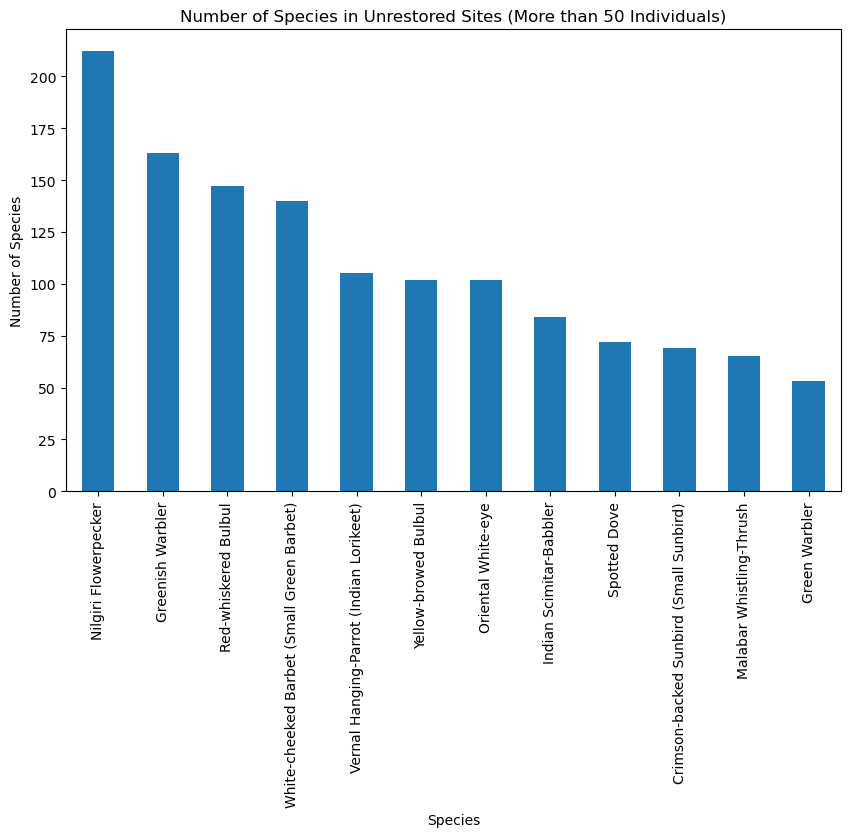

In [14]:
#plot graph of unrestored Site_type Species and Species number only if there are more than 50 individuals 

#on the x-axis plot the Species, on the y-axis plot the number of Species 
import matplotlib.pyplot as plt
unrestored_data=imported_data[imported_data['Site_type']=='Unrestored'] 
species_counts=unrestored_data['Species'].value_counts()        
filtered_species_counts=species_counts[species_counts>50]
plt.figure(figsize=(10,6))
filtered_species_counts.plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Number of Species')
plt.title('Number of Species in Unrestored Sites (More than 50 Individuals)')
plt.show()

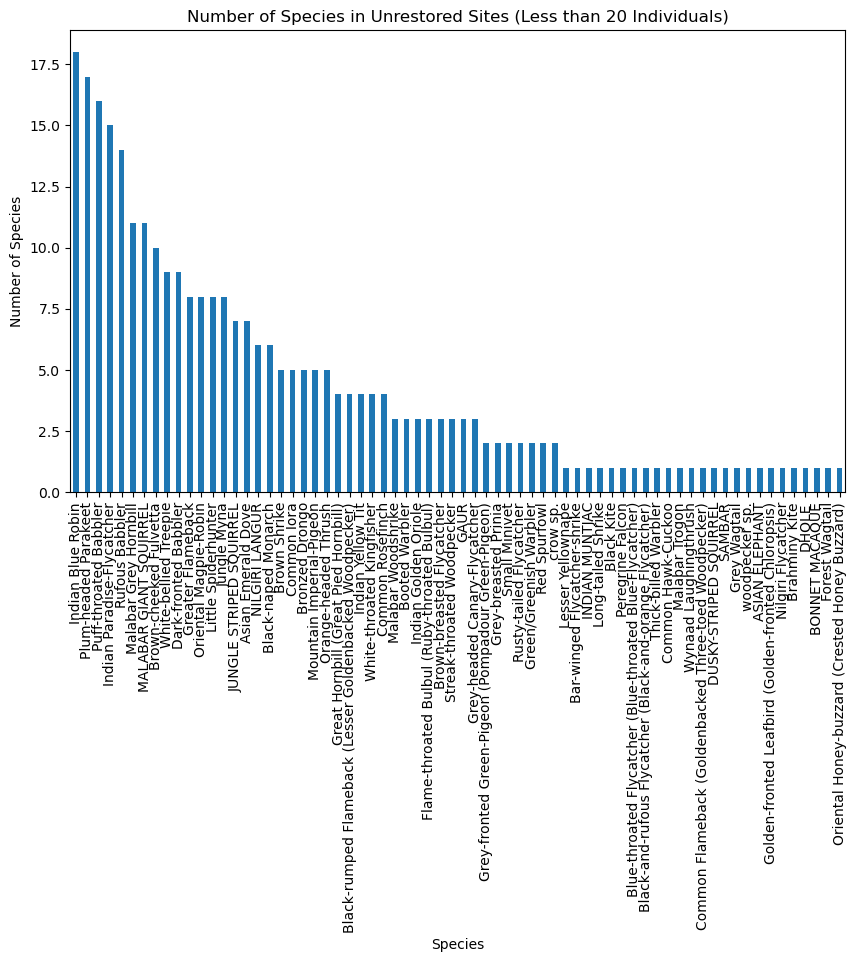

In [15]:
#plot graph of unrestored Site_type Species and Species number only if there are less than 20 individuals 

#on the x-axis plot the Species, on the y-axis plot the number of Species 
import matplotlib.pyplot as plt
unrestored_data=imported_data[imported_data['Site_type']=='Unrestored']
species_counts=unrestored_data['Species'].value_counts()    
filtered_species_counts=species_counts[species_counts<20]
plt.figure(figsize=(10,6))
filtered_species_counts.plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Number of Species')
plt.title('Number of Species in Unrestored Sites (Less than 20 Individuals)')
plt.show()

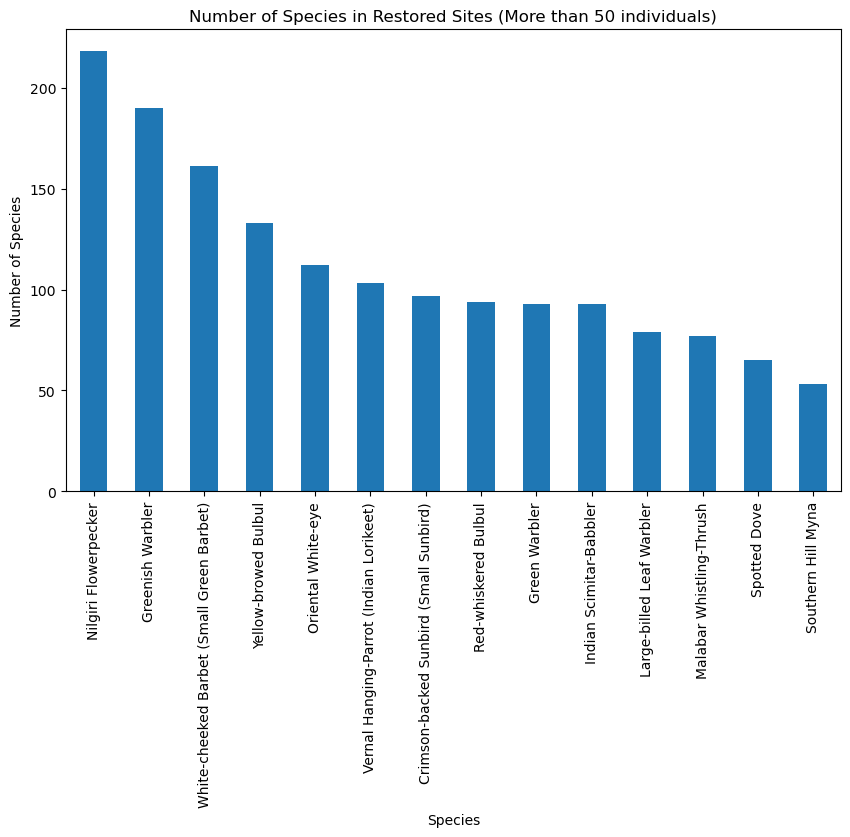

In [16]:
#plot graph of restored Site_type Species and Species number only if there are more than 50 individuals 

#on the x-axis plot the Species, on the y-axis plot the number of Species 
import matplotlib.pyplot as plt
restored_data=imported_data[imported_data['Site_type']=='Restored'] 
species_counts=restored_data['Species'].value_counts()
filtered_species_counts=species_counts[species_counts>50]
plt.figure(figsize=(10,6))
filtered_species_counts.plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Number of Species')
plt.title('Number of Species in Restored Sites (More than 50 individuals)')
plt.show()

In [17]:
#import a .csv file and print its top 10 lines
import pandas as pd

imported_data=pd.read_csv('final_project_data.csv')
#print its top 10 lines
print(imported_data.head(10))

          Date   Site_ID Site_type  StartTime  TimeSeg BirdMamm  \
0  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
1  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
2  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
3  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
4  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
5  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
6  2019-Nov-05  VAR2_10R  Restored       6.46        1   MAMMAL   
7  2019-Nov-05  VAR2_10R  Restored       6.46        1     Bird   
8  2019-Nov-05  VAR2_10R  Restored       6.46        2     Bird   
9  2019-Nov-05  VAR2_10R  Restored       6.46        2     Bird   

                                   Species  Number  Distance HSF Remarks  
0                         Greenish Warbler       1         5   H     NaN  
1                Large-billed Leaf Warbler       1        30   H     NaN  
2                     Yellow-browed B

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_csv("final_project_data.csv")

# Define target and features
y = df["Site_type"]
X = df[["StartTime", "TimeSeg", "Species", "Number", "Distance", "HSF"]]

# Preprocessing
categorical = ["Species", "HSF"]
numeric = ["StartTime", "TimeSeg", "Number", "Distance"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numeric)
])

# Build model
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit model
rf_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
#test the rf_model using the x_test and y_test
predictions = rf_model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[316 143  94]
 [159 210 130]
 [145 145 151]]
              precision    recall  f1-score   support

   Benchmark       0.51      0.57      0.54       553
    Restored       0.42      0.42      0.42       499
  Unrestored       0.40      0.34      0.37       441

    accuracy                           0.45      1493
   macro avg       0.44      0.44      0.44      1493
weighted avg       0.45      0.45      0.45      1493



- Organinise this data to predict the possibility of a certain bird species belonging to one of the habitat types. 
- Sample size is too small (was not done over enough years)

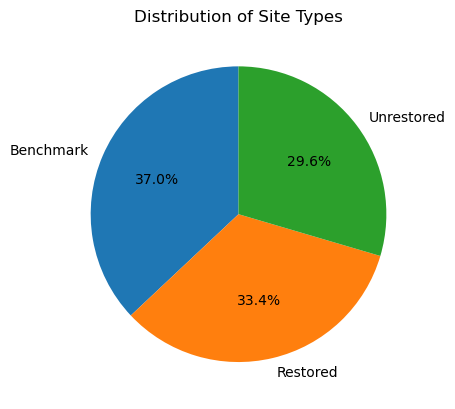

In [20]:
import matplotlib.pyplot as plt

# Count restored vs unrestored sites
site_type_counts = df["Site_type"].value_counts()

# Pie chart
site_type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Site Types')
plt.ylabel('')   # remove y-label for cleaner look
plt.show()

- Pie chart above shows the proportion of bird survey records that come from the different habitat types.

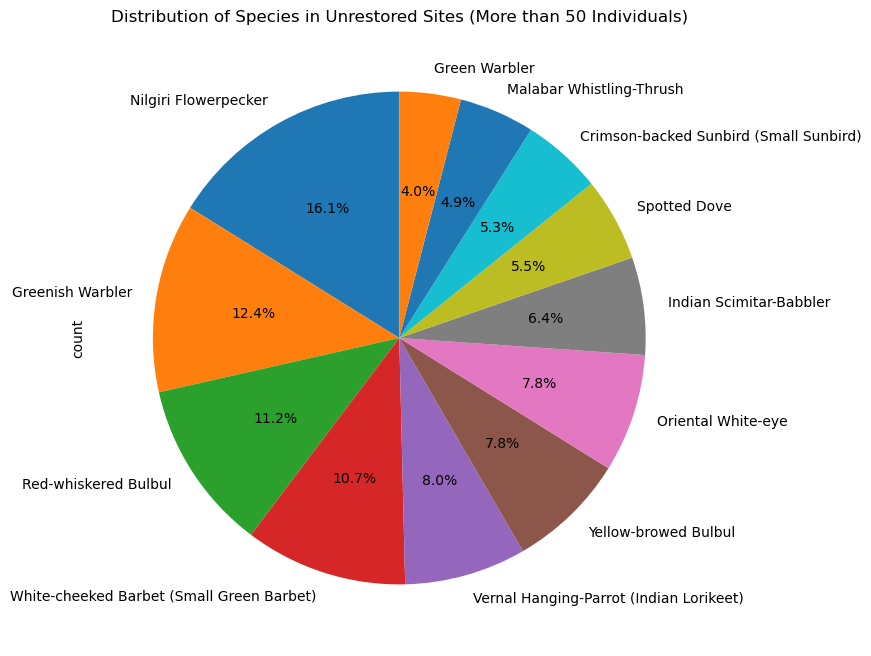

In [21]:
# plot a pie chart of unrestored Site_type Species and Species number only if there are more than 50 individuals 
unrestored_data=df[df['Site_type']=='Unrestored']
species_counts=unrestored_data['Species'].value_counts()
filtered_species_counts=species_counts[species_counts>50]
plt.figure(figsize=(8,8))
filtered_species_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Species in Unrestored Sites (More than 50 Individuals)') 
plt.show()


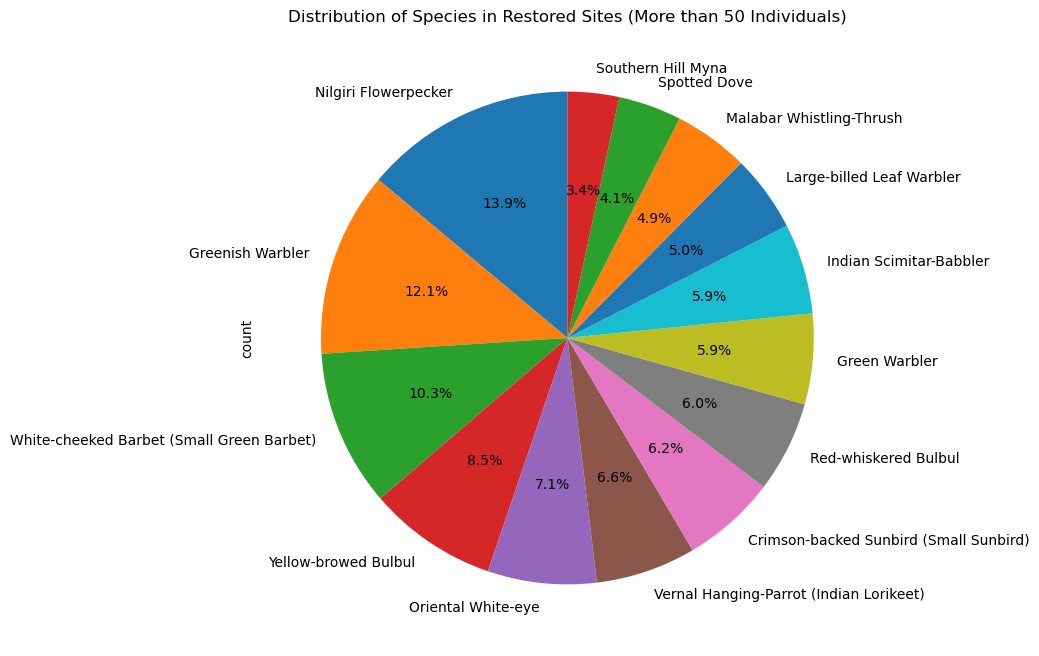

In [22]:
# plot a pie chart of restored Site_type Species and Species number only if there are more than 50 individuals 
unrestored_data=df[df['Site_type']=='Restored']
species_counts=unrestored_data['Species'].value_counts()
filtered_species_counts=species_counts[species_counts>50]
plt.figure(figsize=(8,8))
filtered_species_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Species in Restored Sites (More than 50 Individuals)') 
plt.show()

<Figure size 1200x700 with 0 Axes>

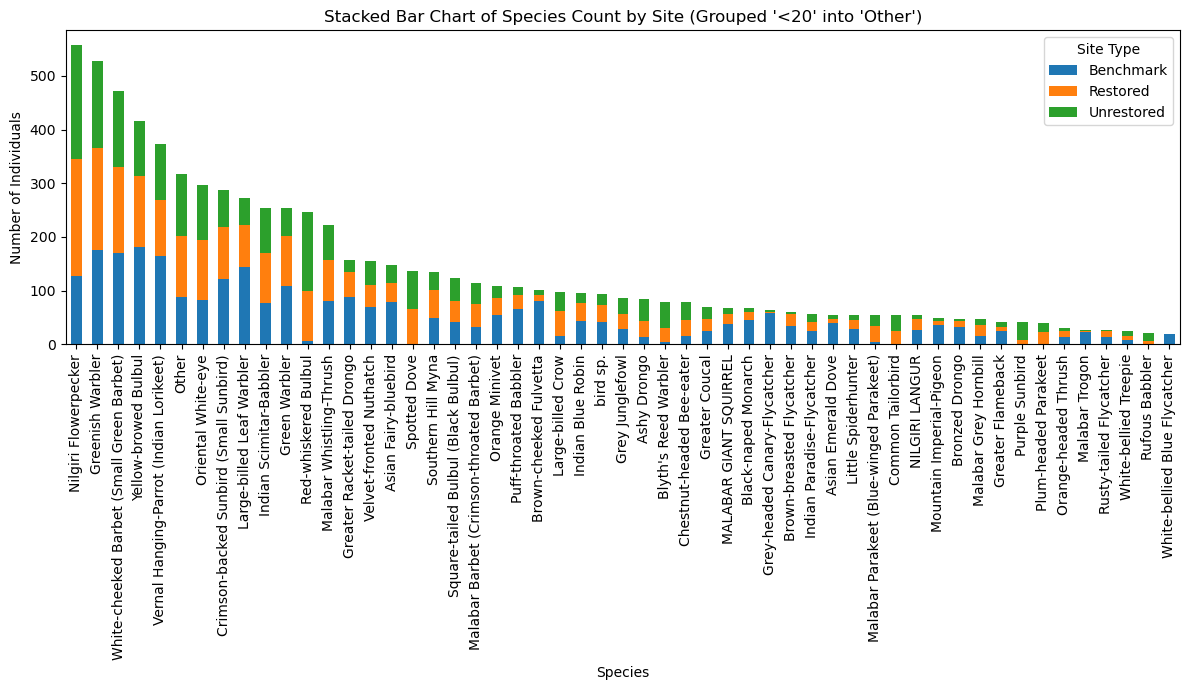

In [26]:
# Count species by Site_type (or other grouping variable)
species_by_site = imported_data.groupby(['Species', 'Site_type']).size().unstack(fill_value=0)

# Collapse species with fewer than 20 individuals across all sites into "Other"
species_totals = species_by_site.sum(axis=1)

# Keep species with >= 20, group others into "Other"
species_kept = species_by_site[species_totals >= 20]
species_other = species_by_site[species_totals < 20].sum().to_frame().T
species_other.index = ['Other']

# Combine back together
species_final = pd.concat([species_kept, species_other])

# Sort species by total descending
species_final = species_final.loc[species_final.sum(axis=1).sort_values(ascending=False).index]

# ---- Plot stacked bar chart ----
plt.figure(figsize=(12, 7))
species_final.plot(kind='bar', stacked=True, figsize=(12,7))

plt.xlabel("Species")
plt.ylabel("Number of Individuals")
plt.title("Stacked Bar Chart of Species Count by Site (Grouped '<20' into 'Other')")
plt.legend(title="Site Type")
plt.tight_layout()
plt.show()

In [28]:
imported_data.columns

Index(['Date', 'Site_ID', 'Site_type', 'StartTime', 'TimeSeg', 'BirdMamm',
       'Species', 'Number', 'Distance', 'HSF', 'Remarks'],
      dtype='object')

In [29]:
possible_site_cols = ['Site', 'site', 'Site_ID', 'Location', 'Plot', 'Point']
site_col = None

for col in imported_data.columns:
    if col in possible_site_cols:
        site_col = col
        break

site_col

'Site_ID'

C:\Users\kempe\AppData\Local\Temp\ipykernel_20556\15773029.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1400x700 with 0 Axes>

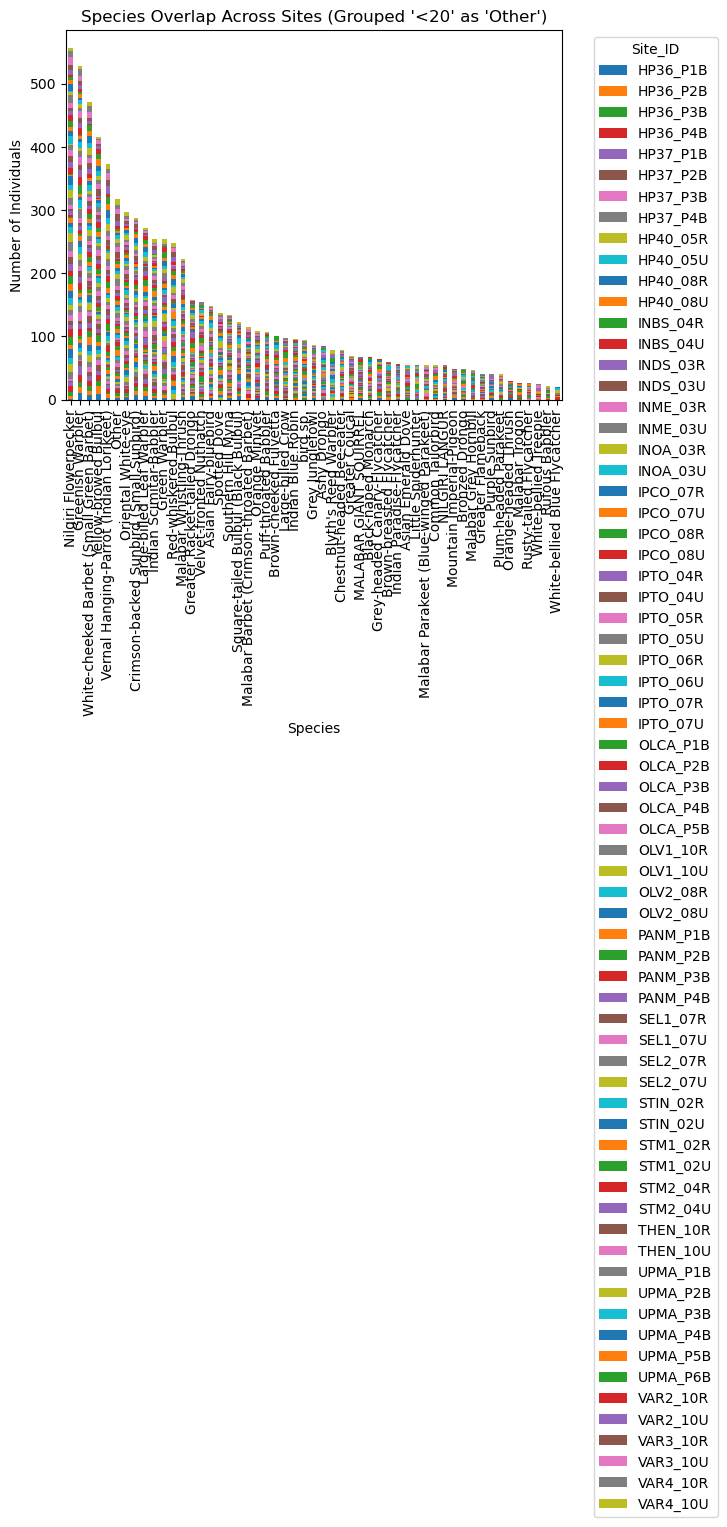

In [30]:
# Count species by Site_ID
species_by_site = imported_data.groupby(['Species', 'Site_ID']).size().unstack(fill_value=0)

# Total individuals per species across all sites
species_totals = species_by_site.sum(axis=1)

# Keep species with >= 20
species_kept = species_by_site[species_totals >= 20]

# Group species with <20 into "Other"
species_other = species_by_site[species_totals < 20].sum().to_frame().T
species_other.index = ['Other']

# Combine back together
species_final = pd.concat([species_kept, species_other])

# Sort species by total abundance
species_final = species_final.loc[
    species_final.sum(axis=1).sort_values(ascending=False).index
]

# ---- Plot stacked bar chart ----
plt.figure(figsize=(14, 7))
species_final.plot(kind='bar', stacked=True)

plt.xlabel("Species")
plt.ylabel("Number of Individuals")
plt.title("Species Overlap Across Sites (Grouped '<20' as 'Other')")
plt.legend(title="Site_ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
species_by_type = imported_data.groupby(['Species', 'Site_type']).size().unstack(fill_value=0)

In [44]:
# Total individuals per species across all site types
species_totals = species_by_type.sum(axis=1)

# Keep species with >= 20 individuals
species_kept = species_by_type[species_totals >= 20]

# Combine species with <20 into "Other"
species_other = species_by_type[species_totals < 20].sum().to_frame().T
species_other.index = ['Other']

# Final clean dataset
species_by_type_final = pd.concat([species_kept, species_other])

# Sort by total abundance
species_by_type_final = species_by_type_final.loc[
    species_by_type_final.sum(axis=1).sort_values(ascending=False).index
]

<Figure size 1200x700 with 0 Axes>

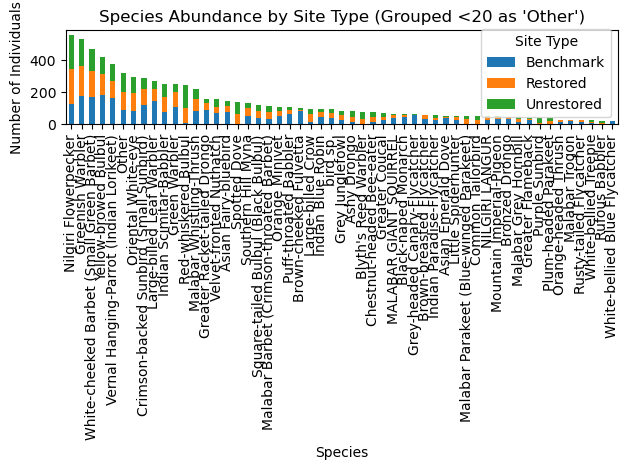

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
species_by_type_final.plot(kind='bar', stacked=True)

plt.xlabel("Species")
plt.ylabel("Number of Individuals")
plt.title("Species Abundance by Site Type (Grouped <20 as 'Other')")
plt.xticks(rotation=90)
plt.legend(title="Site Type")
plt.tight_layout()
plt.show()